In [1]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [2]:
ALL_Data =  pd.read_csv("All_features.csv",index_col="Date",parse_dates=["Date"]).dropna()
ALL_Data["Traget_HDFC"] = ALL_Data["HDFCBANK"].shift(-1)

In [5]:
ALL_Data.drop("HDFCBANK" ,axis =1,inplace =  True)

In [7]:
ALL_Data.dropna(inplace =True)

In [9]:
X = ALL_Data[['NIFTY50', 'BANKNIFTY', 'SENSEX', 'INDIA_VIX', 'USDINR', 'SP500',
       'NASDAQ100', 'DOWJONES', 'NIKKEI225', 'HANGSENG', 'GOLD', 'BRENT_OIL',
       'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK']]

In [11]:
Y  = ALL_Data["Traget_HDFC"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [15]:
# Step 4: Apply Elastic Net Regression
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha = 1, l1_ratio = 0.5)
elastic_net.fit(X_train, Y_train) #Train the model


ElasticNet(alpha=1)

In [17]:
# Step 5: Get Intercept and Coeff for Elastic Net Regression
coefficients = elastic_net.coef_
coefficients
intercept = elastic_net.intercept_
intercept
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})
coeff_df


,Feature,Coefficient
0,NIFTY50,-1.383332
1,BANKNIFTY,0.007399
2,SENSEX,-0.917800
3,INDIA_VIX,-0.158193
4,USDINR,1.931517
5,SP500,-0.132086
6,NASDAQ100,0.106575
7,DOWJONES,0.032591
8,NIKKEI225,0.007495
9,HANGSENG,-0.131070


In [19]:
# Step 6: Predict using Elastic Net Regression
y_pred = elastic_net.predict(X_test)
y_pred


array([ 736.22410634,  554.25024015,  383.94395401, 1122.6989994 ,
        889.69479364,  772.5776812 ,  686.43202494,  886.27987553,
       1159.17212887,  468.78716724,  884.86696742,  626.33047315,
        662.32195927,  586.74721602,  513.69273713,  409.24628327,
        499.53358231,  632.63740403,  489.64232272,  604.91833799,
        636.99055974,  787.72880945,  688.94973526,  479.51557738,
        457.89345482, 1093.36375352,  840.0768452 ,  427.12564696,
       1197.2137961 ,  503.15375758,  813.61774558, 1146.40577909,
        536.15887795,  427.48006601,  512.86071909,  752.25270938,
        817.81244589,  576.38248363,  607.57761255,  600.88528818,
        506.72587723, 1054.53960737, 1206.66531501,  500.76669348,
        459.52688068,  528.01417672,  444.02457956,  511.40673145,
        504.24376057,  520.89431842,  667.58222077,  736.24913389,
        547.60730105,  557.08345701,  490.72484341, 1069.83214643,
        580.8188165 ,  871.31720457,  458.20713929,  554.34296

In [21]:
# Step 7: Create a dataframe with Actual and Predicted Values
df_result = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
df_result

,Actual,Predicted
Date,,
2022-04-27,776.557556,736.224106
2018-03-07,517.742554,554.250240
2016-02-17,388.419128,383.943954
2025-08-19,1080.199951,1122.698999
2023-02-10,856.830017,889.694794
...,...,...
2019-03-28,761.470947,710.051182
2019-06-21,758.735779,690.889690
2015-07-30,559.624207,492.139247


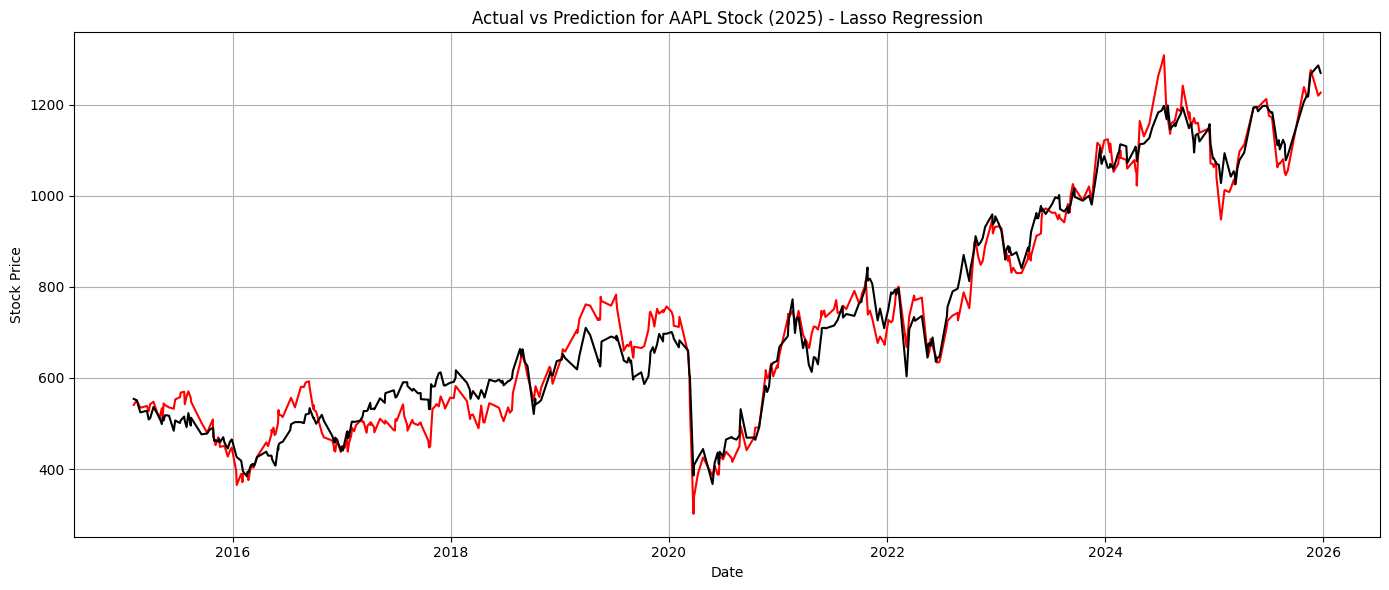

In [23]:
import matplotlib.pyplot as plt
df_result = df_result.sort_index()
plt.figure(figsize = (14,6))
plt.plot(df_result.index, df_result['Actual'], label = 'Actual', color ='red')
plt.plot(df_result.index, df_result['Predicted'], label = 'Predicted', color  ='Black')
plt.title("Actual vs Prediction for AAPL Stock (2025) - Lasso Regression")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y_test, y_pred)
print("R square", r2)
mse = mean_squared_error(Y_test, y_pred)
print("mse",mse)
rmse = np.sqrt(mse)
print("rmse", rmse)

R square 0.9665373369414243
mse 1984.381108454081
rmse 44.546392765902844
